# Epoch Spring Camp 2026 - Take Home Task 3

In this task, you will build and compare two recommender system models:

- **Matrix Factorization (MF)** using a dot product of embeddings  
- **Neural Collaborative Filtering (MLP-based)** using a multi-layer perceptron  

You are provided with:
- Preprocessed interaction data
- Evaluation pipeline

You are expected to implement:
- Negative sampling
- Model architectures
- Training loop

---

The purpose of this task is to understand how neural networks can model user–item interactions beyond simple similarity.

## Imports

In [49]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Loading Data

We begin by loading the interaction data.

In [50]:
df = pd.read_csv("/content/interactions.csv")  # columns: user_id, movie_id

print("Num users:", df['user_id'].nunique())
print("Num items:", df['item_id'].nunique())
print("Num interactions:", len(df))

Num users: 942
Num items: 1447
Num interactions: 55375


Each row represents a **positive interaction** (implicit feedback).

## Train / Test Split

We split the data into training and testing sets.

The model will learn from the training data and be evaluated on unseen interactions in the test set.

In [51]:
from sklearn.model_selection import train_test_split

train_df,test_df = train_test_split(df,test_size=0.2,random_state=42)

## Negative Sampling

The dataset only contains **positive interactions** (user interacted with item).

However, to train a model, we also need **negative examples** (user did not interact with item).

---

### Why do we need this?

We treat recommendation as a **binary classification problem**:

- Positive interaction → label = 1  
- No interaction → label = 0  

Since we don’t have explicit negatives, we **sample them**.

---

### Your Task

For each `(user, item)` interaction:
- Keep it as a **positive sample (label = 1)**
- Sample one or more items the user has **not interacted with**
  - Add them as **negative samples (label = 0)**

---

### Hints

- You can randomly sample items
- Make sure sampled negatives are **not already in the dataset**
- You may use a `set` of `(user, item)` pairs for fast lookup

---

Implement a function:
`sample_negatives(df, num_neg=1)`
that returns a dataframe with columns:
`[user, item, label]`

In [52]:
def sample_negatives(df, num_neg=1):
    """
    For each positive interaction, sample `num_neg` negative items the user hasn't interacted with.
    Returns a DataFrame with columns: [user, item, label]
    """
    all_items = set(df['item_id'].unique())
    # Build a set of known (user, item) pairs for fast lookup
    interacted = set(zip(df['user_id'], df['item_id']))

    rows = []
    for _, row in df.iterrows():
        u=int(row['user_id'])
        i=int(row['item_id'])

        # Add positive sample
        rows.append({'user': u, 'item': i, 'label': 1})

        # Sample negatives
        sampled = 0
        while sampled < num_neg:
            neg = int(np.random.choice(list(all_items)))
            if (u, neg) not in interacted:
                rows.append({'user': u, 'item': neg, 'label': 0})
                sampled += 1

    return pd.DataFrame(rows)


## PyTorch Dataset

We now wrap our processed data into a PyTorch `Dataset`.

This allows us to:
- Access individual samples as `(user, item, label)`
- Easily plug into a `DataLoader` for batching

You do not need to modify this part.

In [53]:
class InteractionDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user'].values)
        self.items = torch.tensor(df['item'].values)
        self.labels = torch.tensor(df['label'].values).float()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

## DataLoader

The `DataLoader` will:
- Batch the data
- Shuffle the training data
- Feed it to the model during training

In [54]:
train_data = sample_negatives(train_df)

train_loader = DataLoader(InteractionDataset(train_data), batch_size=256, shuffle=True)

Why are we sampling negatives only for the training data?

Answer:- The test set uses a different evaluation strategy (hit_at_k) samples its own fresh negatives at eval time, mixing 1 positive with 100 random negatives and checking if the model ranks the real item in the top K. Contaminating the test set with pre-sampled negatives would make the evaluation less meaningful and harder to control.

## Quick Exploration

Before building models, take a moment to explore the data.

Try to understand:
- How many interactions each user has
- How popular certain items are

This can give intuition about the dataset.

In [55]:
# Interactions per user
user_counts = df['user_id'].value_counts()
print(user_counts.describe())
print()

# Interactions per item
item_counts = df['item_id'].value_counts()
print(item_counts.describe())

count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
Name: count, dtype: float64

count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: count, dtype: float64


## Baseline Model: Matrix Factorization (MF)

We represent:
- Each **user** as a vector (embedding)
- Each **item** as a vector (embedding)

To predict interaction:
- Compute the **dot product** between user and item embeddings

This gives a **score** indicating how likely the user is to interact with the item.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Computes their dot product as the output score

In [56]:
class MF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32):
        super().__init__()
        # Embedding layers map integer IDs to dense vectors
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        # Optional: learned biases per user and item improve performance
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)

        # Initialise weights with small values for stable training
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user, item):
        u = self.user_emb(user)          # (batch, emb_dim)
        v = self.item_emb(item)          # (batch, emb_dim)

        # Dot product: element-wise multiply then sum along embedding dimension
        dot = (u * v).sum(dim=1)

        # Add biases
        bias = self.user_bias(user).squeeze() + self.item_bias(item).squeeze()

        return dot + bias


## Training the MF Model

Now train your Matrix Factorization model.

You will need to:
- Define a loss function
- Define an optimizer
- Iterate over the DataLoader
- Update model parameters

---

### Hints

- Use **Binary Cross Entropy loss**
- Apply **sigmoid** to model outputs if needed
- Typical steps:
  - forward pass
  - compute loss
  - backward pass
  - optimizer step

In [57]:
def train(model, dataloader, epochs=10, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # BCEWithLogitsLoss = Sigmoid + Binary Cross-Entropy in one numerically stable op
    criterion = nn.BCEWithLogitsLoss()

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for user, item, label in dataloader:
            user = user.to(device)
            item = item.to(device)
            label = label.to(device)

            optimizer.zero_grad()
            preds = model(user,item)
            loss = criterion(preds,label)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)
        print(f'Epoch {epoch+1}/{epochs}  Loss: {total_loss:.4f}')

    return losses


## Evaluation (Hit@K)

We evaluate the model using a ranking-based metric.

For each user:
- Take one positive item
- Sample multiple negative items
- Rank all items using the model
- Check if the positive item is in the top-K

This is called **Hit@K**.

In [58]:
def hit_at_k(model, test_df, full_df, K=10, num_neg=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    hits = 0
    total = len(df) # We evaluate every positive interaction in the test set

    # Map interactions for quick lookup
    interacted_items = full_df.groupby('user_id')['item_id'].apply(set).to_dict()
    all_items = full_df['item_id'].unique()

    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for _, row in df.iterrows():
            u = int(row['user_id'])
            pos_item = int(row['item_id'])

            # 1. Sample Negatives
            negatives = []
            while len(negatives) < num_neg:
                neg_item = np.random.choice(all_items)
                if neg_item not in interacted_items.get(u, set()):
                    negatives.append(neg_item)

            # 2. Prepare Tensors
            # We need a list of the 1 positive + 100 negatives
            item_list = [pos_item] + negatives
            user_tensor = torch.tensor([u] * (num_neg + 1)).to(device)
            item_tensor = torch.tensor(item_list).to(device)

            # 3. Get Scores
            scores = model(user_tensor, item_tensor)

            # 4. Rank and Check Hit
            # We want to see if the item at index 0 (the positive) is in the top K
            # torch.topk returns values and indices of the highest scores
            _, top_indices = torch.topk(scores, K)

            top_indices = top_indices.cpu().numpy()
            if 0 in top_indices:
                hits += 1

    return hits / total

# TODO:
# 1. Initialize MF model
# 2. Train it
# 3. Evaluate it

If your score is low, try playing with the hyperparameters before moving on! Try sampling more negatives, or playing with the embedding dimensions.

Conversely, if your score is high, play with the values of K or number of negatives in evaluation (dec K, inc negatives).

In [59]:
# Initialise and train the MF model
num_users = df['user_id'].nunique()
num_items = df['item_id'].nunique()

mf_model = MF(num_users=num_users, num_items=num_items, emb_dim=32)

mf_losses = train(mf_model, train_loader, epochs=10, lr=1e-3)

# Evaluate
mf_hit = hit_at_k(mf_model, test_df, df, K=10, num_neg=100)
print(f"\nMF  Hit@10 = {mf_hit:.4f}")


Epoch 1/10  Loss: 232.8319
Epoch 2/10  Loss: 188.6488
Epoch 3/10  Loss: 167.5937
Epoch 4/10  Loss: 161.3060
Epoch 5/10  Loss: 156.6119
Epoch 6/10  Loss: 151.6018
Epoch 7/10  Loss: 146.4296
Epoch 8/10  Loss: 141.4224
Epoch 9/10  Loss: 136.2122
Epoch 10/10  Loss: 131.8318

MF  Hit@10 = 0.6746


## Neural Model: MLP-Based Recommender

Instead of using a dot product, we can learn a more flexible interaction function using a neural network.

Approach:
- Learn user and item embeddings
- **Concatenate** them
- Pass through a **Multi-Layer Perceptron (MLP)**

This allows the model to capture more complex relationships than simple similarity.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Concatenates them
3. Passes them through an MLP to produce a score

The choice of activation functions is upto you.

In [60]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32):
        super().__init__()

        # concatenate the two vectors and feed them into a small network
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

        # After concat the input width is emb_dim * 2.
        # We progressively halve the width so the network is forced to compress
        # the interaction signal down to a single score.
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)   # raw logit – BCEWithLogitsLoss handles sigmoid
        )

    def forward(self, user, item):
        u = self.user_emb(user)   # (batch, emb_dim)
        v = self.item_emb(item)   # (batch, emb_dim)

        x = torch.cat([u, v], dim=1)   # (batch, emb_dim * 2)

        out = self.mlp(x)              # (batch, 1)
        return out.squeeze()           # (batch,)  – matches label shape


## Train and Evaluate the MLP Model

Repeat the same steps as before:
- Train the model
- Evaluate on the test set

Compare its performance with the MF model.

Epoch 1/10  Loss: 205.5458
Epoch 2/10  Loss: 179.8135
Epoch 3/10  Loss: 173.3016
Epoch 4/10  Loss: 169.2592
Epoch 5/10  Loss: 166.6021
Epoch 6/10  Loss: 164.5762
Epoch 7/10  Loss: 161.7758
Epoch 8/10  Loss: 158.1545
Epoch 9/10  Loss: 153.6435
Epoch 10/10  Loss: 149.2000


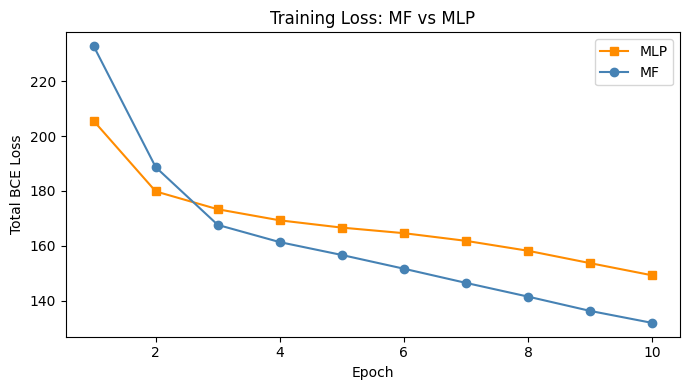

MLP Hit@10 = 0.5842

MF matched or beat MLP


In [61]:
mlp_model = MLP(num_users=num_users, num_items=num_items, emb_dim=32)

mlp_losses = train(mlp_model, train_loader, epochs=10, lr=1e-3)

# Plot MLP training loss alongside MF
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(mlp_losses) + 1), mlp_losses, marker='s', color='darkorange', label='MLP')
plt.plot(range(1, len(mf_losses) + 1),  mf_losses,  marker='o', color='steelblue',  label='MF')
plt.title("Training Loss: MF vs MLP")
plt.xlabel("Epoch")
plt.ylabel("Total BCE Loss")
plt.legend()
plt.tight_layout()
plt.show()

mlp_hit = hit_at_k(mlp_model, test_df, df, K=10, num_neg=100)
print(f"MLP Hit@10 = {mlp_hit:.4f}")
print()
if mlp_hit > mf_hit:
    print("MLP outperforms MF")
else:
    print("MF matched or beat MLP")


## Comparison & Analysis

You have now implemented:
- Matrix Factorization (MF)
- MLP-based recommender

---

### Compare the Models

- What score did each model achieve?
- Which model performed better?

---

### Think & Reflect

- Why might the MLP model outperform MF?
- In what cases might MF perform just as well or better?
- How does embedding size affect performance?
- Did you observe any signs of overfitting?

---

### Some Experiments

If you want to explore further:
- Try different embedding dimensions
- Change number of MLP layers
- Try different activation functions

---

## Bonus Task: Neural Collaborative Filtering (NCF)

In this task, you implemented:
- Matrix Factorization (MF)
- MLP-based recommender

The paper [Neural Collaborative Filtering](https://arxiv.org/pdf/1708.05031) proposes combining both ideas.

---

### Idea

- MF captures **linear interactions**
- MLP captures **nonlinear interactions**

NCF combines both by:
1. Computing MF output
2. Computing MLP output
3. Combining them into a final prediction

---

### Your Task

Design a model that:
- Uses both MF and MLP components
- Combines their outputs
- Trains end-to-end

---

### Hints

- You can:
  - Concatenate MF and MLP representations
  - Or combine their final scores
- Think about:
  - Should embeddings be shared or separate?
  - How to balance both components?

---

Does combining both approaches improve performance over MF and MLP individually?

In [62]:
class NCF(nn.Module):
    """
        Separate embeddings for MF and MLP branches
        The MF branch needs embeddings optimised for dot-product similarity.
        The MLP branch needs embeddings optimised for concatenation + non-linear layers.
        Sharing embeddings forces a compromise,keeping them separate lets each
        branch learn what it needs independently.
        Their outputs are concatenated and fed into a final linear layer that
        learns how to combine both signals into one interaction score.
    """

    def __init__(self, num_users, num_items, emb_dim=32):
        super().__init__()

        # MF branch embeddings
        self.mf_user_emb = nn.Embedding(num_users, emb_dim)
        self.mf_item_emb = nn.Embedding(num_items, emb_dim)

        # MLP branch embeddings
        self.mlp_user_emb = nn.Embedding(num_users, emb_dim)
        self.mlp_item_emb = nn.Embedding(num_items, emb_dim)

        # MLP layers
        self.mlp_layers = nn.Sequential(
            nn.Linear(emb_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )

        # Final prediction layer
        # mf_out shape: (batch, emb_dim)   element-wise product of MF embeddings
        # mlp_out shape: (batch, 16)       output of last MLP layer
        # concatenated → (batch, emb_dim + 16), projected to a single logit
        self.final = nn.Linear(emb_dim + 16, 1)

        # Weight initialisation
        for emb in [self.mf_user_emb, self.mf_item_emb,
                    self.mlp_user_emb, self.mlp_item_emb]:
            nn.init.normal_(emb.weight, std=0.01)

    def forward(self, user, item):
        # MF branch
        mf_u = self.mf_user_emb(user)           # (batch, emb_dim)
        mf_i = self.mf_item_emb(item)           # (batch, emb_dim)
        mf_out = mf_u * mf_i                      # (batch, emb_dim)  not summed yet

        # MLP branch
        mlp_u = self.mlp_user_emb(user)         # (batch, emb_dim)
        mlp_i = self.mlp_item_emb(item)         # (batch, emb_dim)
        mlp_in = torch.cat([mlp_u, mlp_i], dim=1) # (batch, emb_dim*2)
        mlp_out = self.mlp_layers(mlp_in)          # (batch, 16)

        # Combine both branches
        combined = torch.cat([mf_out, mlp_out], dim=1)  # (batch, emb_dim+16)
        logit = self.final(combined)                  # (batch, 1)
        return logit.squeeze(-1)                         # (batch,)


In [63]:
# Train NCF
ncf_model = NCF(num_users=num_users, num_items=num_items, emb_dim=32)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"NCF parameters: {count_params(ncf_model)}")
print(f"MLP parameters: {count_params(mlp_model)}")
print(f"MF parameters: {count_params(mf_model)}")
print()

print("Training NCF")
ncf_losses = train(ncf_model, train_loader, epochs=10, lr=1e-3)

# Evaluate
ncf_hit = hit_at_k(ncf_model, test_df, df, K=10, num_neg=100)
print(f"\nNCF Hit@10 = {ncf_hit:.4f}")


NCF parameters: 159713
MLP parameters: 83233
MF parameters: 78837

Training NCF
Epoch 1/10  Loss: 188.3501
Epoch 2/10  Loss: 162.3907
Epoch 3/10  Loss: 143.6148
Epoch 4/10  Loss: 125.5540
Epoch 5/10  Loss: 111.0433
Epoch 6/10  Loss: 98.2503
Epoch 7/10  Loss: 86.3686
Epoch 8/10  Loss: 75.7187
Epoch 9/10  Loss: 66.0251
Epoch 10/10  Loss: 57.4145

NCF Hit@10 = 0.7687


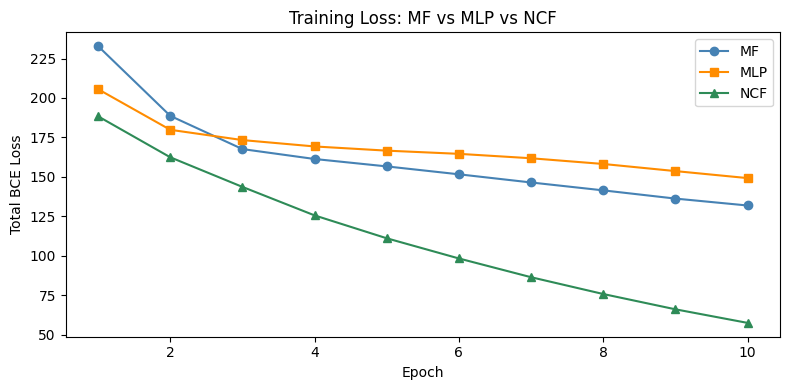


MF Hit@10=0.6746
MLP Hit@10=0.5842
NCF Hit@10=0.7687

Best model: NCF


In [64]:
# Loss curves: all three models
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), mf_losses,  marker='o', color='steelblue',  label='MF')
plt.plot(range(1, 11), mlp_losses, marker='s', color='darkorange', label='MLP')
plt.plot(range(1, 11), ncf_losses, marker='^', color='seagreen',   label='NCF')
plt.title("Training Loss: MF vs MLP vs NCF")
plt.xlabel("Epoch")
plt.ylabel("Total BCE Loss")
plt.legend()
plt.tight_layout()
plt.show()

models = ['MF', 'MLP', 'NCF']
scores = [mf_hit, mlp_hit, ncf_hit]

print(f"\nMF Hit@10={mf_hit:.4f}")
print(f"MLP Hit@10={mlp_hit:.4f}")
print(f"NCF Hit@10={ncf_hit:.4f}")
best = models[scores.index(max(scores))]
print(f"\nBest model: {best}")
